## Descriptions
This script is for plotting all the WRF output from Yagi (2024) simulations

In [1]:
# __diagnose_wrf_notebook_setup__
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "data"
WRF_DIR = DATA_DIR / "wrfout"
BEST_TRACK_DIR = DATA_DIR / "best_tracks"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


In [2]:
import numpy as np
from diagnose_wrf import legacy_plot as wrf
import importlib 
from pathlib import Path
from diagnose_wrf import workflow as wf
from IPython.display import HTML, display
import matplotlib.pyplot as plt

In [3]:
files = sorted(WRF_DIR.glob("wrfout_d03_2024-09-06_*"))
fig, ani = wf.plot_animation_d03(
    files,
    varname="QVAPOR",
    levels=None,
    level_count=21,
    level_index=0,
    time_index=0,
    latlon_bounds=None,
    index_bounds=None,
    cmap_name="viridis",
    min_color=(0.9, 0.9, 1.0),
    max_color=(0.0, 0.0, 1.0),
    neg_color=(0.0, 0.0, 1.0),
    pos_color=(1.0, 0.0, 0.0),
    percentiles=(2, 98),
    interval_ms=300,
    figsize=(8, 6),
    xlabel_fontsize=None,
    ylabel_fontsize=None,
    x_tick_count=None,
    y_tick_count=None,
    repeat=True,
    cache_frames=True,    
)

animation = True
if animation == True:
    plt.close(fig)   # optional: hides the static first-frame figure
    display(HTML(ani.to_jshtml()))
    ani.save(OUTPUT_DIR / "T2_animation.gif", writer="pillow", fps=3)

min index is (np.int64(231), np.int64(345))
min index is (np.int64(34), np.int64(474))
min index is (np.int64(235), np.int64(340))
min index is (np.int64(34), np.int64(474))
min index is (np.int64(242), np.int64(339))
min index is (np.int64(34), np.int64(474))
min index is (np.int64(249), np.int64(338))
min index is (np.int64(18), np.int64(304))
min index is (np.int64(261), np.int64(337))
min index is (np.int64(34), np.int64(475))
min index is (np.int64(273), np.int64(329))
min index is (np.int64(3), np.int64(495))
min index is (np.int64(277), np.int64(321))
min index is (np.int64(34), np.int64(474))
min index is (np.int64(275), np.int64(309))
min index is (np.int64(3), np.int64(495))
min index is (np.int64(271), np.int64(306))
min index is (np.int64(34), np.int64(475))
min index is (np.int64(274), np.int64(302))
min index is (np.int64(34), np.int64(474))
min index is (np.int64(274), np.int64(302))
min index is (np.int64(1), np.int64(513))
min index is (np.int64(276), np.int64(299))
mi

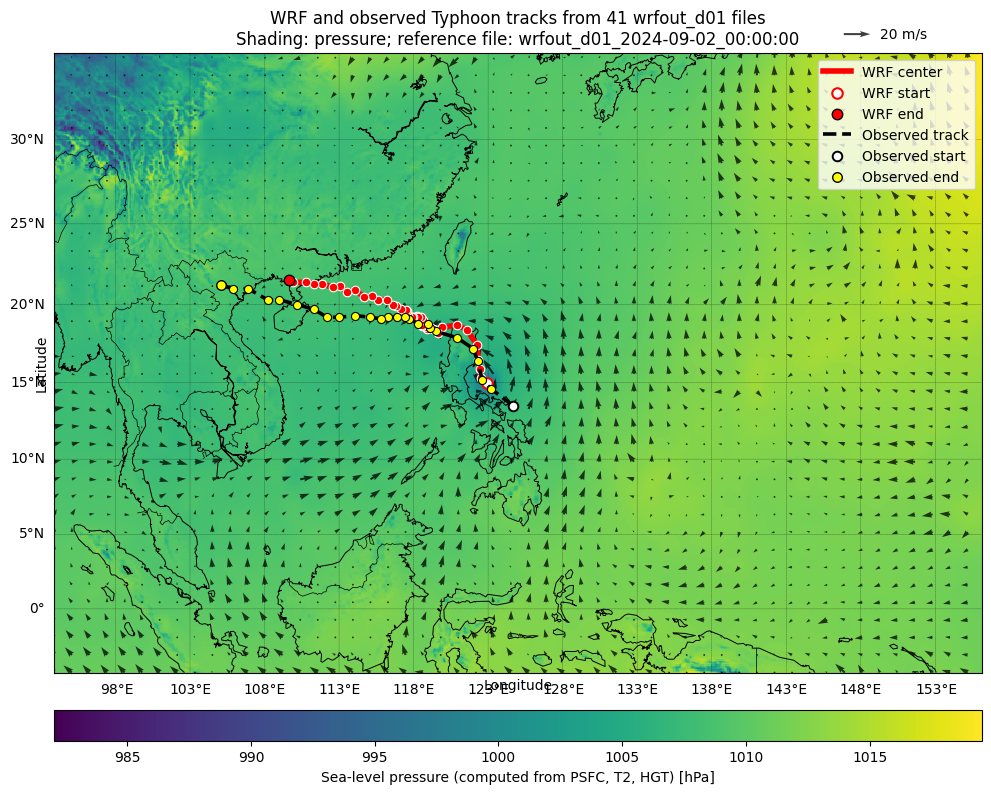

In [4]:
importlib.reload(wf)
files = sorted(WRF_DIR.glob("wrfout_d01_*"))

fig, track_rows, obs_rows = wf.plot_track(
    files,
    observed_track_file=BEST_TRACK_DIR / "bwp122024.dat",
    shading_var="pressure",
    target_pressure_hpa=750.0,
    overlay_vectors=True,
    model_track_color="red",
    observed_track_color="black",
    track_output_file=OUTPUT_DIR / "yagi_model_track.csv",
    time_index=0,
    shading_level_index=0,
    vector_u_var="U10",
    vector_v_var="V10",
    vector_level_index=0,
    center_agreement_km=100.0,
    max_ocean_hgt_m=100.0,
    max_center_jump_km_per_6h=50.0,
    center_jump_reference_hours=6.0,
    pressure_var_candidates=("SLP", "slp", "PMSL", "MSLP", "PSFC"),
    landmask_var_candidates=("LANDMASK", "XLAND"),
    shading_levels=None,
    shading_level_count=24,
    shading_percentiles=(1, 99),
    shading_cmap_name="viridis",
    shading_min_color=(0.95, 0.95, 1.0),
    shading_max_color=(0.0, 0.15, 0.75),
    shading_neg_color=(0.0, 0.0, 1.0),
    shading_pos_color=(1.0, 0.0, 0.0),
    model_track_marker_face="red",
    model_track_marker_edge="white",
    model_track_linewidth=4.0,
    model_track_marker_size=38,
    observed_track_marker_face="yellow",
    observed_track_marker_edge=None,
    observed_track_linewidth=2.6,
    observed_track_marker_size=34,
    observed_track_linestyle="--",
    vector_skip=14,
    vector_scale=700,
    vector_width=0.0022,
    vector_alpha=0.75,
    vector_color="black",
    vector_key=20,
    xlabel_fontsize=None,
    ylabel_fontsize=None,
    xtick_fontsize=None,
    ytick_fontsize=None,
    x_tick_count=None,
    y_tick_count=None,
    map_resolution="l",
    figsize=(10, 8),
    include_track_in_map_extent=True,
    map_margin_degrees=1.0,
    track_slice=None,
    diagnostics_output_file=None,
    save_path=None,
    return_data=True,
)

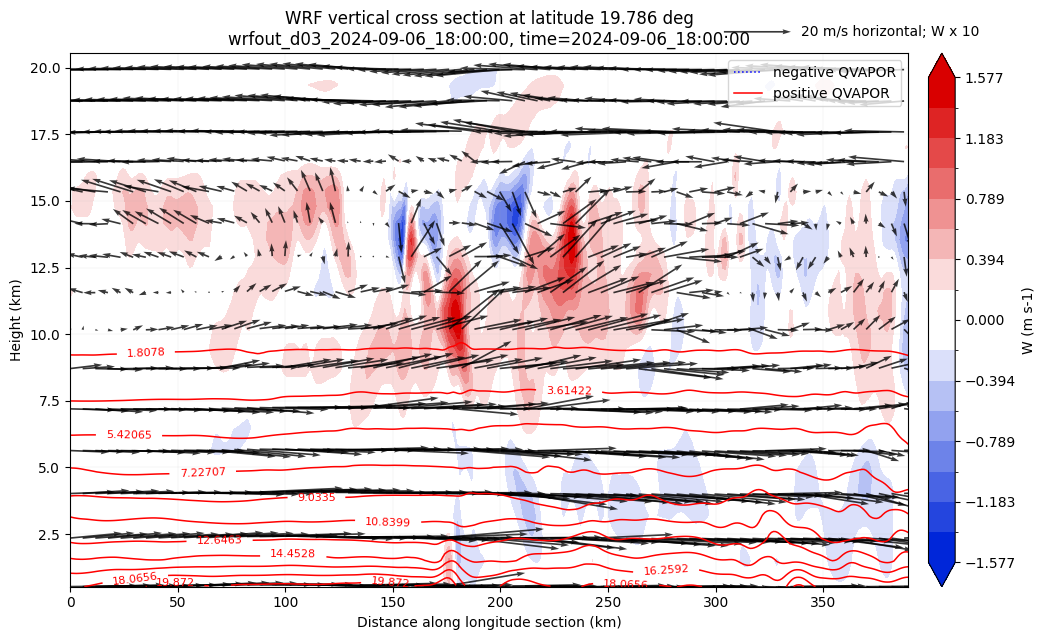

In [5]:
#files = sorted(WRF_DIR.glob("wrfout_d03_*"))
files = [WRF_DIR / "wrfout_d03_2024-09-06_18:00:00"]

fig = wf.plot_vertical_cross_section(
    files,
    file_index=0,
    cross_section_axis="lat",
    section_value=19.2,
    lev1=0,
    lev2=30,
    shading_var="W",
    contour_var="QVAPOR",
    vector_horizontal_var="auto",
    vector_vertical_var="W",
    time_index=0,
    vertical_axis="height_km",
    shading_levels=None,
    contour_levels=None,
    shading_level_count=17,
    contour_level_count=13,
    shading_symmetric_about_zero=True,
    contour_symmetric_about_zero=True,
    variable_scale=None,
    variable_units_override=None,
    negative_shade_color=(0.0, 0.15, 0.85),
    positive_shade_color=(0.85, 0.0, 0.0),
    neutral_color=(1.0, 1.0, 1.0),
    negative_contour_color="blue",
    positive_contour_color="red",
    zero_contour_color="black",
    negative_contour_linestyle="dotted",
    positive_contour_linestyle="solid",
    contour_linewidth=1.1,
    contour_label_fontsize=8,
    plot_vectors=True,
    vector_skip_horizontal=6,
    vector_skip_vertical=2,
    vertical_wind_display_multiplier=10.0,
    vector_scale=250,
    vector_width=0.002,
    vector_alpha=0.78,
    vector_key_horizontal_value=20,
    figsize=(11, 6.5),
    xlabel_fontsize=None,
    ylabel_fontsize=None,
    x_tick_count=None,
    y_tick_count=None,
    save_path=None,
    return_data=False,
)

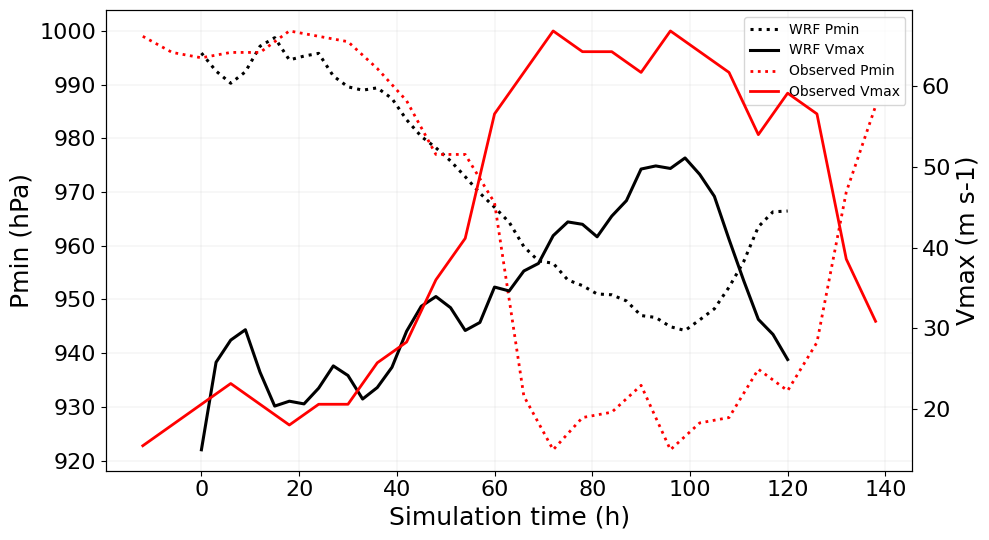

In [6]:
files = sorted(WRF_DIR.glob("wrfout_d01_*"))
fig, model_rows, obs_rows = wf.plot_vortex_intensity_timeseries(
    files,
    observed_track_file=BEST_TRACK_DIR/"bwp122024.dat",
    csv_output_file=OUTPUT_DIR/"model_vortex_intensity.csv",
    time_index=0,
    max_pmin_vmax_distance_km=180.0,
    max_ocean_hgt_m=100.0,
    pressure_var_candidates=("SLP", "slp", "PMSL", "MSLP", "PSFC"),
    landmask_var_candidates=("LANDMASK", "XLAND"),
    time_axis="hours",
    model_vmax_scale=1.0,
    observed_vmax_scale=0.514444,
    vmax_units="m s-1",
    figsize=(10, 5.5),
    xlabel_fontsize=18,
    pmin_ylabel_fontsize=18,
    vmax_ylabel_fontsize=18,
    xtick_fontsize=16,
    ytick_fontsize=16,
    x_tick_count=None,
    pmin_tick_count=None,
    vmax_tick_count=None,
    model_pmin_color="black",
    model_vmax_color="black",
    model_pmin_linewidth=2.2,
    model_vmax_linewidth=2.2,
    model_pmin_linestyle="dotted",
    model_vmax_linestyle="solid",
    observed_pmin_color="red",
    observed_vmax_color="red",
    observed_pmin_linewidth=2.0,
    observed_vmax_linewidth=2.0,
    observed_pmin_linestyle="dotted",
    observed_vmax_linestyle="solid",
    marker=None,
    observed_marker=None,
    grid=True,
    title=None,
    invert_pmin_axis=False,
    save_path=None,
    return_data=True,  
)

## Plot 3D fields

In [65]:
# open input file
df,dx,nx,ny,nz = wrf.loadWRF(WRF_DIR / "wrfout_d02_2024-09-06_08:00:00")
#df,dx,nx,ny,nz = wrf.loadWRF(WRF_DIR / "wrfout_d01_2024-09-06_12:00:00")
df

A-grid dim (dx,nx,ny,nz) for /geode3/home/u020/ckieu/BigRed200/model/diagnosePy/data/wrfout/wrfout_d02_2024-09-06_08:00:00 are (np.float32(3000.0), 813, 534, 30)


<xarray.Dataset> Size: 1GB
Dimensions:                (Time: 1, south_north: 534, west_east: 813,
                            bottom_top: 30, bottom_top_stag: 31,
                            soil_layers_stag: 4, west_east_stag: 814,
                            south_north_stag: 535, seed_dim_stag: 2)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 2MB 12.03 ....
    XLONG                  (Time, south_north, west_east) float32 2MB 104.0 ....
    XTIME                  (Time) datetime64[ns] 8B 2024-09-06T08:00:00
    XLAT_U                 (Time, south_north, west_east_stag) float32 2MB 12...
    XLONG_U                (Time, south_north, west_east_stag) float32 2MB 10...
    XLAT_V                 (Time, south_north_stag, west_east) float32 2MB 12...
    XLONG_V                (Time, south_north_stag, west_east) float32 2MB 10...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, seed_dim_stag
Data variables: (12/204)
    Times                  (Time) |S19 19B b'2024-09-06_08:00:00'
    LU_INDEX               (Time, south_north, west_east) float32 2MB 2.0 ......
    ZNU                    (Time, bottom_top) float32 120B 0.9415 ... 0.002745
    ZNW                    (Time, bottom_top_stag) float32 124B 1.0 ... 0.0
    ZS                     (Time, soil_layers_stag) float32 16B 0.05 ... 1.5
    DZS                    (Time, soil_layers_stag) float32 16B 0.1 0.3 0.6 1.0
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 2MB 0.0 ......
    PC                     (Time, south_north, west_east) float32 2MB 0.0 ......
    LANDMASK               (Time, south_north, west_east) float32 2MB 1.0 ......
    LAKEMASK               (Time, south_north, west_east) float32 2MB 0.0 ......
    SST                    (Time, south_north, west_east) float32 2MB 295.7 ....
    SST_INPUT              (Time, south_north, west_east) float32 2MB 0.0 ......
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.7.1 MODEL
    START_DATE:                      2024-09-02_00:00:00
    SIMULATION_START_DATE:           2024-09-02_00:00:00
    WEST-EAST_GRID_DIMENSION:        814
    SOUTH-NORTH_GRID_DIMENSION:      535
    BOTTOM-TOP_GRID_DIMENSION:       31
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      0
    ETAC:                            0.0

In [66]:
# create an object for WRF 3D variables
importlib.reload(wrf)
p3d = wrf.var3D(nz=nz,ny=ny,nx=nx,dx=dx/1000)
print(str(df.XTIME.values[0])[:-10])
p3d.__dict__

2024-09-06T08:00:00


{'nx': 813,
 'ny': 534,
 'nz': 30,
 'nx1': 814,
 'ny1': 535,
 'nz1': 31,
 'dx': np.float32(3.0)}

Plotting default color range


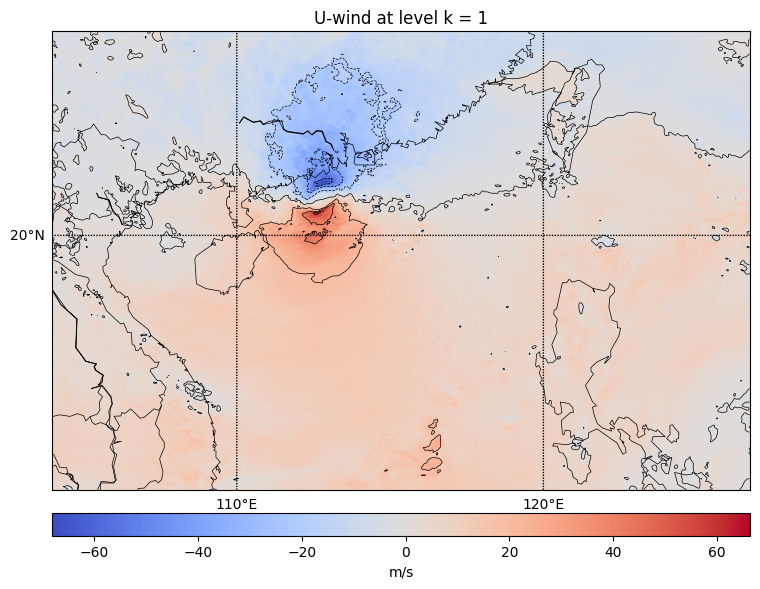

'\np3d.plot_zlevel_grid3D(u1,cvar=u1,ilev=plevel,\n                       u3d=u1,v3d=v1,\n                       rs=1,re=ny-1,cs=1,ce=nx-1,\n                       title=title,clevs=clevs,                              \n                       minc=min_color,maxc=max_color,\n                       ccolor=ccolor,cthick=0.2,\n                       labels=colorbar_label,\n                       vector=True,\n                       scale=500,skipx=30,skipy=30)\n'

In [67]:
# plot u
u1 = p3d.shiftU3D(df.U.values)
v1 = p3d.shiftV3D(df.V.values)
clevs = [-999]                             # default color levels and scheme
#clevs=[-20, -15, -10,-5,0,5,10,15,20], # my own color levels
min_color = (0,0.5,0)                   # my own color scheme
max_color = (0,0.9,0)                   # my own color scheme
ccolor = "black"
title = "U-wind"
colorbar_label = "m/s"
plevel = 1                              # level to plot
p3d.plot_zlevel_world3D(df,u1,cvar=u1,ilev=plevel,
                         slat=0,elat=31,slon=100,elon=135,
                         title=title,clevs=clevs,                              
                         minc=min_color,maxc=max_color,
                         ccolor=ccolor,cthick=0.5,
                         labels=colorbar_label)
'''
p3d.plot_zlevel_grid3D(u1,cvar=u1,ilev=plevel,
                       u3d=u1,v3d=v1,
                       rs=1,re=ny-1,cs=1,ce=nx-1,
                       title=title,clevs=clevs,                              
                       minc=min_color,maxc=max_color,
                       ccolor=ccolor,cthick=0.2,
                       labels=colorbar_label,
                       vector=True,
                       scale=500,skipx=30,skipy=30)
'''

Plotting customized color range


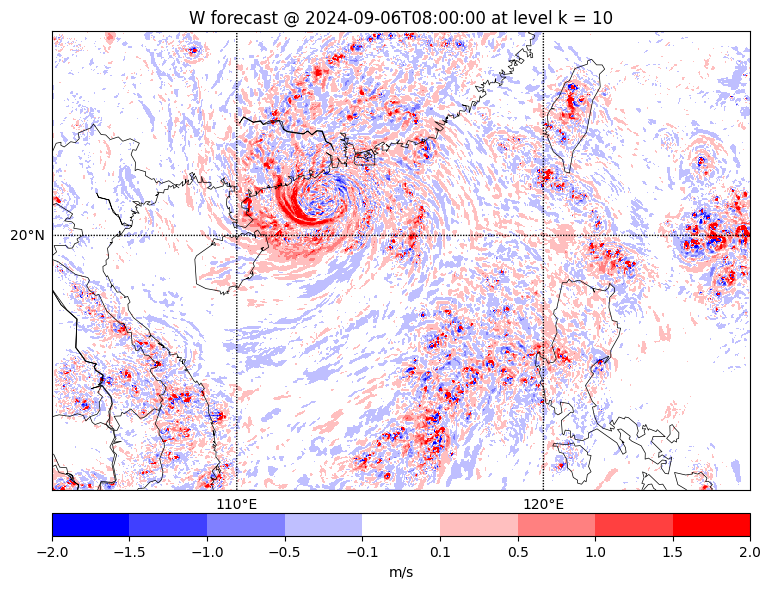

In [68]:
importlib.reload(wrf)
w1 = df.W.values[0]
#clevs = [-999]                       # default color levels and scheme
clevs=[-2.0, -1.5, -1.0,-0.5,-0.1, 0.1, 0.5, 1.0, 1.5, 2.0] # my own color levels
min_color = (0,0,1)                   # my own color scheme
max_color = (1,0,0)                   # my own color scheme
title = f"W forecast @ {str(df.XTIME.values[0])[:-10]}"
colorbar_label = "m/s"
plevel = 10                           # level to plot
ccolor = "black"
p3d.plot_zlevel_world3D(df,w1,ilev=plevel,cvar=w1,
                         slat=0,elat=31,slon=100,elon=135,
                         title=title,clevs=clevs,                              
                         minc=min_color,maxc=max_color,
                         ccolor=ccolor,cthick=0.0,
                         labels=colorbar_label)

Plotting customized color range


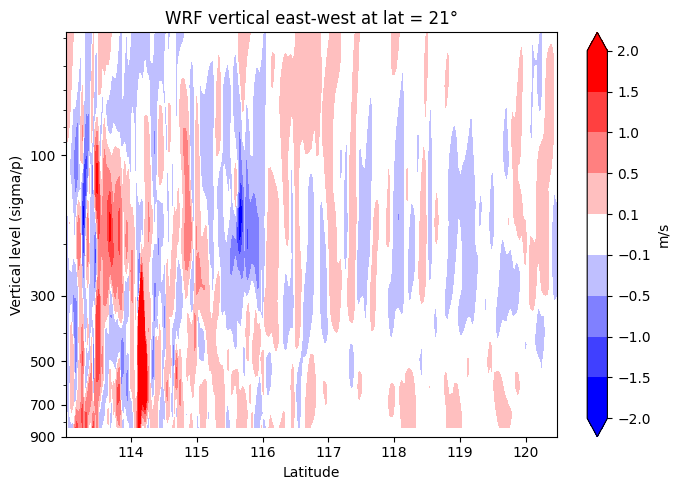

In [69]:
# plot vertical cross section
importlib.reload(wrf)
w1 = df.W.values[0]
w2 = (w1[:nz] + w1[1:nz+1])/2.
#clevs = [-999]                       # default color levels and scheme
clevs=[-2.0, -1.5, -1.0,-0.5,-0.1, 0.1, 0.5, 1.0, 1.5, 2.0] # my own color levels
min_color = (0,0,1)                   # my own color scheme
max_color = (1,0,0)                   # my own color scheme
title = "W-wind"
colorbar_label = "m/s"
plevel = 10                           # level to plot
p3d.plot_xSection_grid3D(df,w2,xlat=21,xlon=-99,
                         slat=0,elat=31,slon=113,elon=120.5,
                         lev1=1,lev2=25,
                         clevs=clevs,ticks=[-1,0,1],
                         labels="m/s",
                         title="WRF vertical east-west",
                         minc=min_color,
                         maxc=max_color,
                         zlev="s",option="shading",cfont=12)

(30, 534, 813)
Plotting customized color range


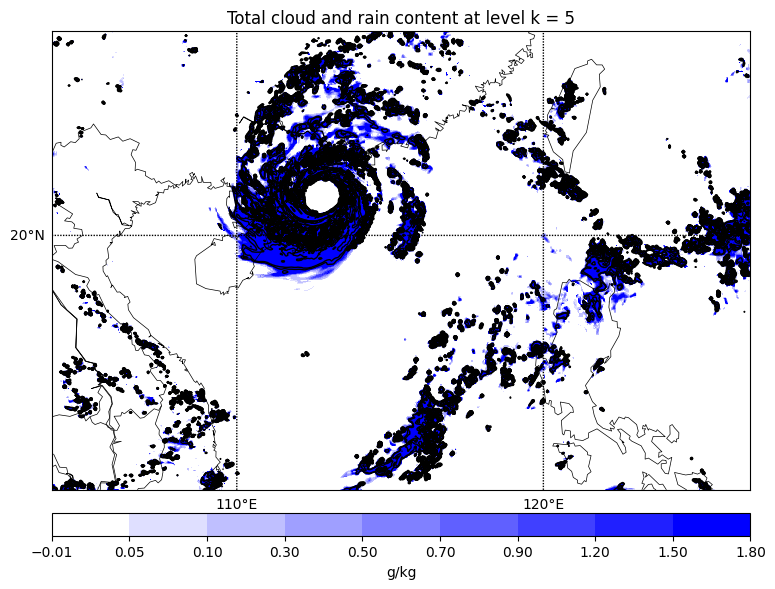

In [79]:
importlib.reload(wrf)
cloud = df.QRAIN.values[0]+df.QCLOUD.values[0]
print(cloud.shape)
#clevs = [-999]                       # default color levels and scheme
clevs=[-0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 1.2, 1.5, 1.8] # my own color levels
min_color = (1,1,1)                   # my own color scheme
max_color = (0,0,1)                   # my own color scheme
title = "Total cloud and rain content"
colorbar_label = "g/kg"
plevel = 5                            # level to plot
p3d.plot_zlevel_world3D(df,cloud*1e5,cvar=cloud*1e3,ilev=plevel,
                         slat=0,elat=31,slon=100,elon=135,
                         title=title,clevs=clevs,                              
                         minc=min_color,maxc=max_color, 
                         labels=colorbar_label)

## Plot 2D fields

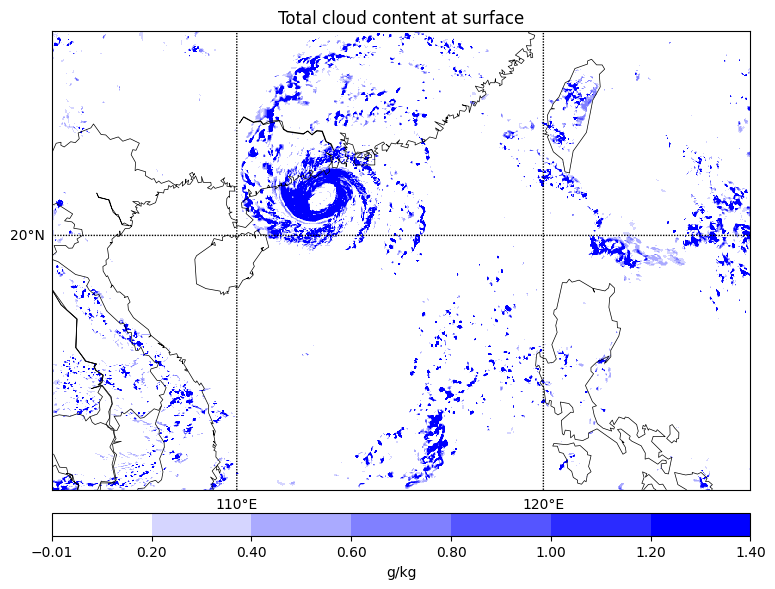

In [73]:
# plot 2D total cloud
importlib.reload(wrf)
p2d = wrf.var2D(ny=ny,nx=nx,dx=dx/1000)
cloud_total = np.sum(df.QCLOUD.values[0], axis=0) 
clevs=[-0.01, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4] # my own color levels
min_color = (1,1,1)                   # my own color scheme
max_color = (0,0,1)                   # my own color scheme
title = "Total cloud and rain content"
colorbar_label = "g/kg"
p2d.plot_surface_world2D(df,cloud_total*1e3,
                         slat=0,elat=31,slon=100,elon=135,
                         title="Total cloud content",
                         clevs=clevs,                              
                         minc=min_color,
                         maxc=max_color,
                         labels="g/kg")

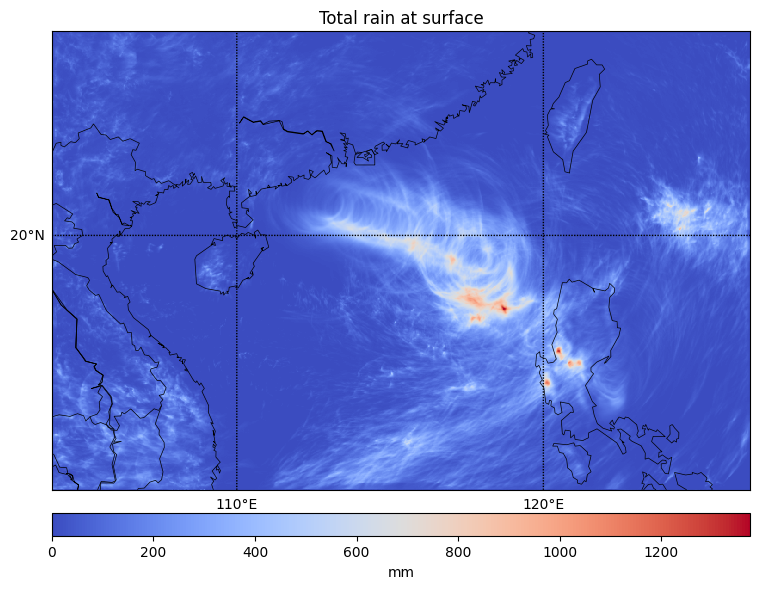

In [72]:
# plot 2D total rain
importlib.reload(wrf)
p2d = wrf.var2D(ny=ny,nx=nx,dx=dx/1000)
rain_total = df.RAINC[0] + df.RAINNC[0]
olr = df.OLR[0]
p2d.plot_surface_world2D(df,rain_total,
                        slat=0,elat=31,slon=100,elon=135,
                        title="Total rain",
                        clevs=[0], # default color levels and scheme                          
                        #clevs=[-20, -15, -10,-5,0,5,10,15,20], # my own color levels
                        minc=(0,0,0),maxc=(0,1,0), # my own color scheme
                        labels="mm")